<a href="https://colab.research.google.com/github/ZahraAlijani/UpperLowerApp/blob/main/steneo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyreadr

import pyreadr
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.2/776.2 kB 13.7 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set correct file paths #first time when I wanted to convert from RDS to csv
file_path = "/content/drive/MyDrive/dom_all.RDS"
output_csv = "/content/drive/MyDrive/dom_all.csv"

try:
    # ✅ Fix: Ensure the correct file path is passed as a string
    data = pyreadr.read_r(file_path)  # Read the RDS file
    df = next(iter(data.values()))  # Extract the dataframe

    # Save as CSV
    df.to_csv(output_csv, index=False)
    print(f"File successfully converted and saved as {output_csv}")
except Exception as e:
    print(f"Error: {e}")


File successfully converted and saved as /content/drive/MyDrive/dom_all.csv


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/dom_all.csv')

In [ ]:
print(data.head())

    rok         DOMAC  HD_BD  VEL  TYP  OBLAST  SKUP  OSOB  EA  EA_S  ...  \
0  2014  1.100110e+09      1    9    1       1     3     2   1     0  ...   
1  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
2  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
3  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
4  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   

   OKNA  KOTEL  ZIMA_TEPLO  PUJC_NAJ  DOMP_PROF  DOMP_MALO  DOMP_PLATI  \
0   NaN    NaN         NaN       NaN        NaN        NaN         NaN   
1   NaN    NaN         NaN       NaN        NaN        NaN         NaN   
2   NaN    NaN         NaN       NaN        NaN        NaN         NaN   
3   NaN    NaN         NaN       NaN        NaN        NaN         NaN   
4   NaN    NaN         NaN       NaN        NaN        NaN         NaN   

   VHD_ZATEZ  HYP_UMOR  HYP_UROK  
0        NaN       NaN       NaN  
1        NaN       NaN

In [ ]:
# Set correct file paths #first time when I wanted to convert from RDS to csv
file_path = "/content/drive/MyDrive/data_STENEO.RDS"
output_csv = "/content/drive/MyDrive/data_STENEO.csv"

try:
    # ✅ Fix: Ensure the correct file path is passed as a string
    data = pyreadr.read_r(file_path)  # Read the RDS file
    df = next(iter(data.values()))  # Extract the dataframe

    # Save as CSV
    df.to_csv(output_csv, index=False)
    print(f"File successfully converted and saved as {output_csv}")
except Exception as e:
    print(f"Error: {e}")


Error: File b'/content/drive/MyDrive/data_STENEO.RDS' does not exist!


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/data_STENEO.csv')

In [ ]:
print(data.head())

    rok  DOMAC  HD_BD  VEL  TYP  OBLAST  SKUP  OSOB  EA  EA_S  ...  nevych  \
0  2024    NaN      1    7    3       2     7     1   0     0  ...    True   
1  2024    NaN      1    7    3       2     1     2   2     0  ...   False   
2  2024    NaN      1    7    3       2     2     1   1     1  ...   False   
3  2024    NaN      1    7    3       2     1     1   1     0  ...   False   
4  2024    NaN      1    8    3       1     1     2   2     0  ...   False   

   bydzat  ch_sub  chudoba24  I3pod    syn           psj  dpsj   dec5    ech  
0    True    True       True  False   True  19475.666667     2   True   True  
1   False   False      False  False  False  32711.862745     8  False  False  
2   False   False      False  False  False  23201.166667     4   True  False  
3   False   False      False  False  False  37768.083333     9  False  False  
4   False    True       True  False  False  44362.745098    10  False  False  

[5 rows x 279 columns]


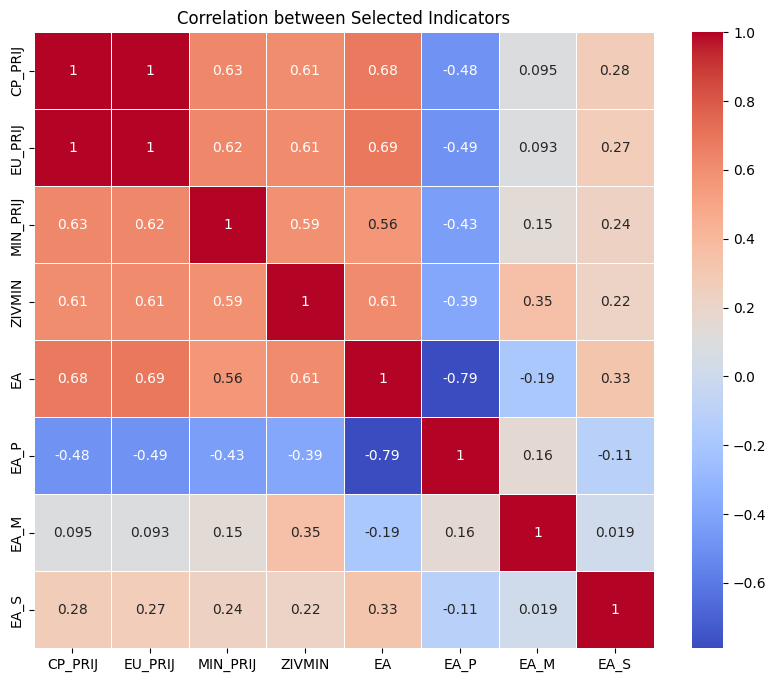

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/data_STENEO.csv')  # <<< replace with your actual path

# Select relevant columns for analysis
columns_of_interest = ['CP_PRIJ', 'EU_PRIJ', 'MIN_PRIJ', 'ZIVMIN', 'EA', 'EA_P', 'EA_M', 'EA_S']
#columns_of_interest = ['ZATEZ_BYDL',  'EU_ZATEZB CP_PRIJ', 'NAJEM ELEKTR', 'DAN HPRIJMY', 'PLYN OSOB']
analysis_df = df[columns_of_interest].dropna()
# Correlation matrix
correlation_matrix = analysis_df.corr()

# Visualize the correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation between Selected Indicators')
plt.show()

# Scatter plots: Income vs Energy Consumption
# Remove or update scatter plots as the new columns are not income/energy consumption related
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=analysis_df['CP_PRIJ'], y=analysis_df['EA'])
# plt.xlabel('Domestic Income (CP_PRIJ)')
# plt.ylabel(' Economical Activity (EA)')
# plt.title('Income vs Economical Activity')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

# Scatter plots: Minimum Income vs Energy Consumption
# plt.figure(figsize=(12, 6))
# sns.scatterplot(x=analysis_df['MIN_PRIJ'], y=analysis_df['EA'])
# plt.xlabel('Minimum Income (MIN_PRIJ)')
# plt.ylabel('Economical Activity (EA)')
# plt.title('Minimum Income vs Economical Activity')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

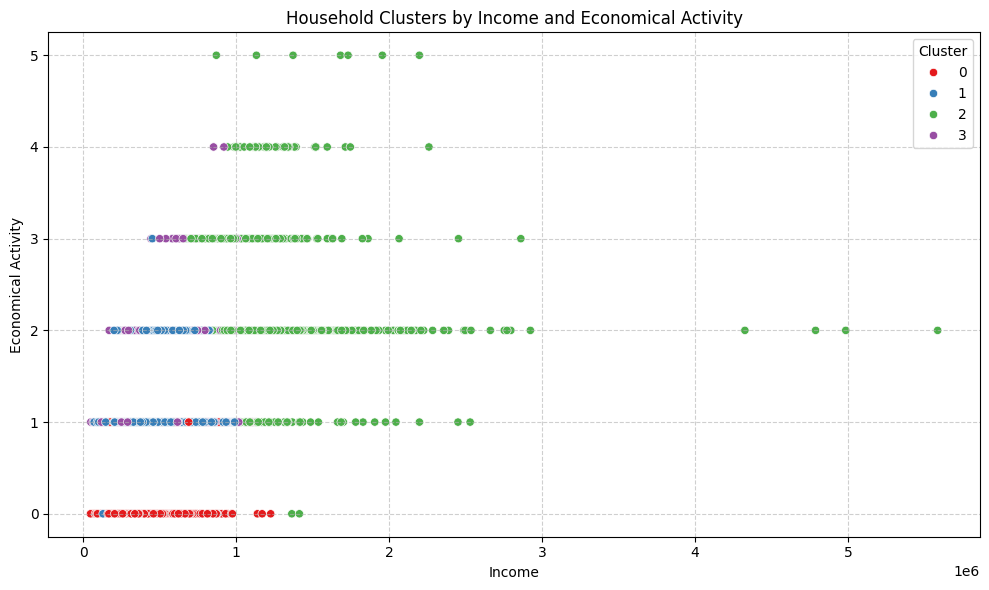

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load your dataset
# Fix: Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/data_STENEO.csv') # Make sure this file is in your working directory

# Select and rename relevant columns
features = ['CP_PRIJ', 'EA', 'EA_P', 'VEL']
df_cluster = df[features].dropna()
df_cluster = df_cluster.rename(columns={
    'CP_PRIJ': 'Income',
    'EA': 'EnergyUse',
    'EA_P': 'EnergyCostIndex',
    'VEL': 'HouseholdSize'
})

# Standardize the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=0)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_features)

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cluster, x='Income', y='EnergyUse', hue='Cluster', palette='Set1')
plt.title("Household Clusters by Income and Economical Activity")
plt.xlabel("Income")
plt.ylabel("Economical Activity")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the plot as PNG
plt.savefig("household_clusters_economical_activity.png")
plt.show()

In [ ]:
# Use the pyreadr library through a workaround to try reading the RDS file
import subprocess

# Set correct file paths #first time when I wanted to convert from RDS to csv
file_path = "/content/drive/MyDrive/dom_2024_echudoba.RDS"
output_csv = "/content/drive/MyDrive/dom_2024_echudoba.csv"

try:
    # ✅ Fix: Ensure the correct file path is passed as a string
    data = pyreadr.read_r(file_path)  # Read the RDS file
    df = next(iter(data.values()))  # Extract the dataframe

    # Save as CSV
    df.to_csv(output_csv, index=False)
    print(f"File successfully converted and saved as {output_csv}")
except Exception as e:
    print(f"Error: {e}")


File successfully converted and saved as /content/drive/MyDrive/dom_2024_echudoba.csv


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/dom_2024_echudoba.csv')

In [ ]:
print(data.head())

    rok  DOMAC  HD_BD  VEL  TYP  OBLAST  SKUP  OSOB  EA  EA_S  ...  nevych  \
0  2024    NaN      1    7    3       2     7     1   0     0  ...    True   
1  2024    NaN      1    7    3       2     1     2   2     0  ...   False   
2  2024    NaN      1    7    3       2     2     1   1     1  ...   False   
3  2024    NaN      1    7    3       2     1     1   1     0  ...   False   
4  2024    NaN      1    8    3       1     1     2   2     0  ...   False   

   bydzat  ch_sub  chudoba24  I3pod    syn           psj  dpsj   dec5    ech  
0    True    True       True  False   True  19475.666667     2   True   True  
1   False   False      False  False  False  32711.862745     8  False  False  
2   False   False      False  False  False  23201.166667     4   True  False  
3   False   False      False  False  False  37768.083333     9  False  False  
4   False    True       True  False  False  44362.745098    10  False  False  

[5 rows x 279 columns]


In [ ]:
print(df.columns)

Index(['rok', 'DOMAC', 'HD_BD', 'VEL', 'TYP', 'OBLAST', 'SKUP', 'OSOB', 'EA',
       'EA_S',
       ...
       'nevych', 'bydzat', 'ch_sub', 'chudoba24', 'I3pod', 'syn', 'psj',
       'dpsj', 'dec5', 'ech'],
      dtype='object', length=279)


In [ ]:
# Set correct file paths #first time when I wanted to convert from RDS to csv
file_path = "/content/drive/MyDrive/ECH_klusacek.RDS"
output_csv = "/content/drive/MyDrive/ECH_klusacek.csv"

try:
    # ✅ Fix: Ensure the correct file path is passed as a string
    data = pyreadr.read_r(file_path)  # Read the RDS file
    df = next(iter(data.values()))  # Extract the dataframe

    # Save as CSV
    df.to_csv(output_csv, index=False)
    print(f"File successfully converted and saved as {output_csv}")
except Exception as e:
    print(f"Error: {e}")


File successfully converted and saved as /content/drive/MyDrive/ECH_klusacek.csv


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ECH_klusacek.csv')

In [ ]:
print(data.head())

    rok         DOMAC  HD_BD  VEL  TYP  OBLAST  SKUP  OSOB  EA  EA_S  ...  \
0  2014  1.100110e+09      1    9    1       1     3     2   1     0  ...   
1  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
2  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
3  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   
4  2014  1.100110e+09      1    9    1       1     7     1   0     0  ...   

   nevych  bydzat  ch_sub  chudoba24     I3    syn           psj  dpsj   dec5  \
0   False   False   False      False  False  False  24642.990196    10  False   
1    True    True    True       True   True   True  16508.000000     7  False   
2    True    True    True       True  False  False  16528.333333     7  False   
3    True    True    True       True   True   True  14008.000000     5   True   
4   False   False   False      False  False  False  25273.416667    10  False   

     ech  
0  False  
1  False  
2  False  
3   Tr

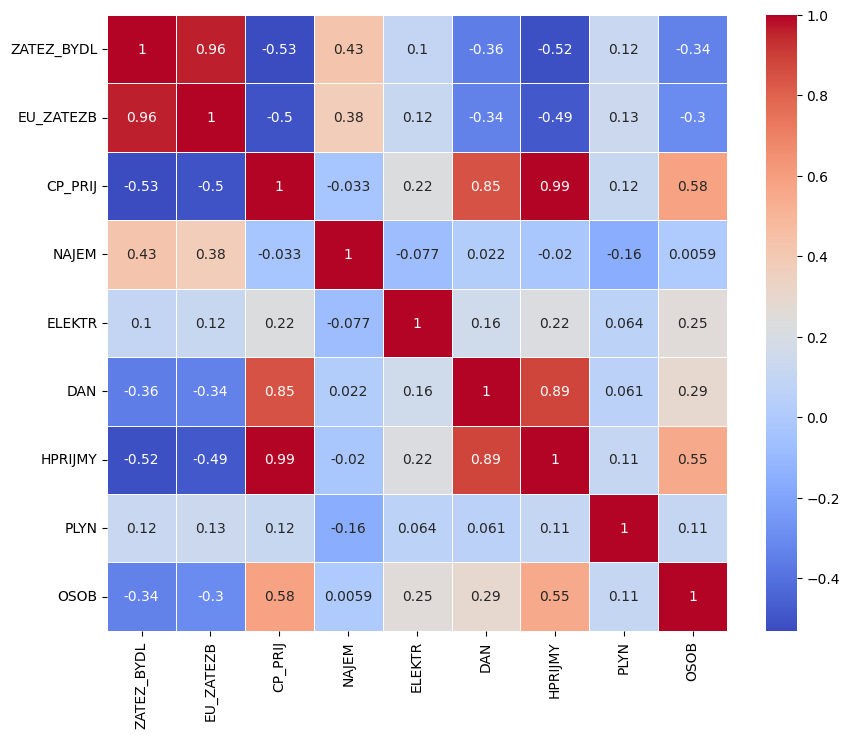

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/ECH_klusacek.csv')  # <<< replace with your actual path

# Select relevant columns for analysis
columns_of_interest = ['ZATEZ_BYDL',  'EU_ZATEZB', 'CP_PRIJ', 'NAJEM', 'ELEKTR', 'DAN', 'HPRIJMY', 'PLYN', 'OSOB']
analysis_df = df[columns_of_interest].dropna()
# Correlation matrix
correlation_matrix = analysis_df.corr()

# Visualize the correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
#plt.title('Correlation between Selected Indicators')
plt.show()


From here  is related to difference equations

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Define a triangular fuzzy number as (left, peak, right)
class TriangularFuzzyNumber:
    def __init__(self, left, peak, right):
        self.left = left
        self.peak = peak
        self.right = right

    def alpha_cut(self, alpha):
        # Compute alpha-cut interval for triangular fuzzy number
        l = self.left + alpha * (self.peak - self.left)
        r = self.right - alpha * (self.right - self.peak)
        return (l, r)

# Complete correlated multiplication for intervals
def correlated_multiply(intervals):
    # intervals is a list of tuples [(l1,r1), (l2,r2), ...]
    # Under complete correlation, multiply corresponding endpoints
    left = np.prod([i[0] for i in intervals])
    right = np.prod([i[1] for i in intervals])
    return (left, right)

# Interactive logistic difference equation using alpha-cuts
def interactive_logistic(beta, x0, iterations=10, alphas=None):
    if alphas is None:
        alphas = np.linspace(0, 1, 11)

    results = []
    current = x0

    for n in range(iterations):
        alpha_intervals = []
        for alpha in alphas:
            beta_interval = beta.alpha_cut(alpha)
            x_interval = current.alpha_cut(alpha)
            one_minus_x = (1 - x_interval[1], 1 - x_interval[0])  # reversed for interval
            next_interval = correlated_multiply([beta_interval, x_interval, one_minus_x])
            alpha_intervals.append(next_interval)
        results.append(alpha_intervals)

        # Update current fuzzy number by taking midpoints of intervals for simplicity
        midpoints = [np.mean(interval) for interval in alpha_intervals]
        current = TriangularFuzzyNumber(min(midpoints), midpoints[len(midpoints)//2], max(midpoints))

    return results

# Define fuzzy parameters
beta = TriangularFuzzyNumber(2.5, 3.0, 3.5)  # growth rate
x0 = TriangularFuzzyNumber(0.1, 0.2, 0.3)    # initial population

# Run simulation
iterations = 15
alphas = np.linspace(0, 1, 11)
results = interactive_logistic(beta, x0, iterations, alphas)

# Prepare data for visualization
alpha0_series = [r[0] for r in results]  # alpha=0 intervals
alpha1_series = [r[-1] for r in results] # alpha=1 intervals

alpha0_mid = [np.mean(interval) for interval in alpha0_series]
alpha1_mid = [np.mean(interval) for interval in alpha1_series]

# Plot evolution of fuzzy intervals
fig = go.Figure()
fig.add_trace(go.Scatter(y=alpha0_mid, x=list(range(iterations)), mode='lines+markers', name='Alpha=0 midpoint'))
fig.add_trace(go.Scatter(y=alpha1_mid, x=list(range(iterations)), mode='lines+markers', name='Alpha=1 midpoint'))

fig.update_layout(title='Interactive Logistic Difference Equation (Fuzzy Evolution)',
                  xaxis_title='Iteration', yaxis_title='Value', template='plotly_white')
fig.show()

In [ ]:

import numpy as np
import plotly.graph_objects as go

# Define a trapezoidal fuzzy number as (a, b, c, d)
class TrapezoidalFuzzyNumber:
    def __init__(self, a, b, c, d):
        self.a = a  # left support
        self.b = b  # left core
        self.c = c  # right core
        self.d = d  # right support

    def alpha_cut(self, alpha):
        # Compute alpha-cut interval for trapezoidal fuzzy number
        if alpha == 0:
            return (self.a, self.d)
        else:
            l = self.a + alpha * (self.b - self.a)
            r = self.d - alpha * (self.d - self.c)
            return (l, r)

# Complete correlated multiplication for intervals
def correlated_multiply(intervals):
    left = np.prod([i[0] for i in intervals])
    right = np.prod([i[1] for i in intervals])
    return (left, right)

# Interactive logistic difference equation using alpha-cuts
def interactive_logistic(beta, x0, iterations=10, alphas=None):
    if alphas is None:
        alphas = np.linspace(0, 1, 11)

    results = []
    current = x0

    for n in range(iterations):
        alpha_intervals = []
        for alpha in alphas:
            beta_interval = beta.alpha_cut(alpha)
            x_interval = current.alpha_cut(alpha)
            one_minus_x = (1 - x_interval[1], 1 - x_interval[0])  # reversed for interval
            next_interval = correlated_multiply([beta_interval, x_interval, one_minus_x])
            alpha_intervals.append(next_interval)
        results.append(alpha_intervals)

        # Update current fuzzy number by taking midpoints of intervals for simplicity
        midpoints = [np.mean(interval) for interval in alpha_intervals]
        current = TrapezoidalFuzzyNumber(min(midpoints),
                                         midpoints[len(midpoints)//3],
                                         midpoints[2*len(midpoints)//3],
                                         max(midpoints))

    return results

# Define fuzzy parameters (trapezoidal)
beta = TrapezoidalFuzzyNumber(2.5, 2.8, 3.2, 3.5)  # growth rate
x0 = TrapezoidalFuzzyNumber(0.1, 0.15, 0.25, 0.3)   # initial population

# Run simulation
iterations = 15
alphas = np.linspace(0, 1, 11)
results = interactive_logistic(beta, x0, iterations, alphas)

# Prepare data for visualization
alpha0_series = [r[0] for r in results]  # alpha=0 intervals
alpha1_series = [r[-1] for r in results] # alpha=1 intervals

alpha0_mid = [np.mean(interval) for interval in alpha0_series]
alpha1_mid = [np.mean(interval) for interval in alpha1_series]

# Plot evolution of fuzzy intervals
fig = go.Figure()
fig.add_trace(go.Scatter(y=alpha0_mid, x=list(range(iterations)), mode='lines+markers', name='Alpha=0 midpoint'))
fig.add_trace(go.Scatter(y=alpha1_mid, x=list(range(iterations)), mode='lines+markers', name='Alpha=1 midpoint'))

fig.update_layout(title='Interactive Logistic Difference Equation (Trapezoidal Fuzzy Evolution)',
                  xaxis_title='Iteration', yaxis_title='Value', template='plotly_white')

fig.show()


This line takes the middle element of the midpoints list and assigns it to both current_r and current_s.
Effectively, it forces both parameters to be equal, even if they were initialized differently.
This is why you observed that the fuzziness collapses toward symmetry.

Initial fuzzy x0: (0.2, 0.3, 0.4)
Fuzzy beta: (2.5, 3.0, 3.5)

Iteration 0:
  α=1: raw interval [0.6300, 0.6300], adjusted width=0.0000
  α=0.75: raw interval [0.5732, 0.6855], adjusted width=0.1088
  α=0.5: raw interval [0.5156, 0.7394], adjusted width=0.1938
  α=0.25: raw interval [0.4577, 0.7910], adjusted width=0.2204
  α=0: raw interval [0.4000, 0.8400], adjusted width=0.0440

Iteration 1:
  α=1: raw interval [0.6993, 0.6993], adjusted width=0.0000
  α=0.75: raw interval [0.6702, 0.7284], adjusted width=0.0564
  α=0.5: raw interval [0.6410, 0.7576], adjusted width=0.1009
  α=0.25: raw interval [0.6119, 0.7867], adjusted width=0.1156
  α=0: raw interval [0.5828, 0.8159], adjusted width=0.0233

Iteration 2:
  α=1: raw interval [0.6308, 0.6308], adjusted width=0.0000
  α=0.75: raw interval [0.6046, 0.6571], adjusted width=0.0509
  α=0.5: raw interval [0.5783, 0.6834], adjusted width=0.0911
  α=0.25: raw interval [0.5520, 0.7097], adjusted width=0.1043
  α=0: raw interval [0.5257, 0.7

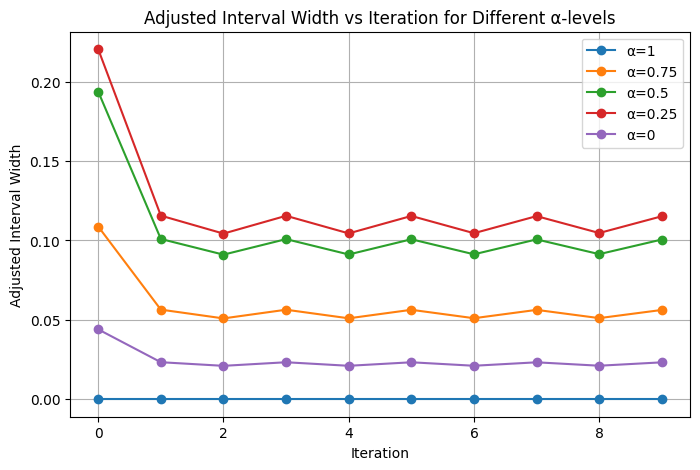

Simulation complete. Plot saved as adjusted_interval_widths.png


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# Parameters
iterations = 10
alpha_levels = [1, 0.75, 0.5, 0.25, 0]  # reverse order

# Initial fuzzy numbers (triangular)
x0 = (0.2, 0.3, 0.4)
beta = (2.5, 3.0, 3.5)

print(f"Initial fuzzy x0: {x0}")
print(f"Fuzzy beta: {beta}")

# Function to compute alpha-cut for triangular fuzzy number
def alpha_cut(tri, alpha):
    a, b, c = tri
    left = a + (b - a) * alpha
    right = c - (c - b) * alpha
    return left, right

# Relativity-inspired adjustment function (Lorentz-like)
def adjust_width(width, alpha):
    # As alpha decreases, uncertainty grows but controlled by nonlinear factor
    # Factor inspired by relativity: gamma = 1 / sqrt(1 - v^2), here v ~ (1 - alpha)
    v = 1 - alpha
    gamma = 1 / np.sqrt(1 - min(v**2, 0.99))  # avoid division by zero
    return width / gamma  # shrink width as gamma grows

# Logistic function
def logistic(beta_val, x_val):
    return beta_val * x_val * (1 - x_val)

# Simulation
widths = {alpha: [] for alpha in alpha_levels}
x_current = x0

for n in range(iterations):
    print(f"\nIteration {n}:")
    new_x_intervals = {}
    for alpha in alpha_levels:
        x_interval = alpha_cut(x_current, alpha)
        beta_interval = alpha_cut(beta, alpha)

        # Compute min and max of f(x) = beta * x * (1 - x)
        candidates = []
        for x_val in x_interval:
            for b_val in beta_interval:
                candidates.append(logistic(b_val, x_val))

        min_val, max_val = min(candidates), max(candidates)

        # Apply relativity-inspired adjustment to width
        adjusted_width = adjust_width(max_val - min_val, alpha)
        widths[alpha].append(adjusted_width)

        # Print intervals for clarity
        print(f"  α={alpha}: raw interval [{min_val:.4f}, {max_val:.4f}], adjusted width={adjusted_width:.4f}")

        new_x_intervals[alpha] = (min_val, max_val)

    # Update x_current using α=1 interval as approximation for next step (core first)
    x_current = (new_x_intervals[1][0], np.mean(new_x_intervals[1]), new_x_intervals[1][1])

# Plot adjusted interval width vs iteration for each alpha
plt.figure(figsize=(8, 5))
for alpha in alpha_levels:
    plt.plot(range(iterations), widths[alpha], marker='o', label=f'α={alpha}')
plt.xlabel('Iteration')
plt.ylabel('Adjusted Interval Width')
plt.title('Adjusted Interval Width vs Iteration for Different α-levels')
plt.legend()
plt.grid(True)
plt.savefig('adjusted_interval_widths.png')
plt.show()

print("Simulation complete. Plot saved as adjusted_interval_widths.png")


From here is not related to difference equations.

Data shape: X=(93425, 12, 5), y=(93425,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Training RNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
RNN MSE: 0.002639
Training LSTM...
584/584 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
LSTM MSE: 0.002649
Training GRU...
584/584 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
GRU MSE: 0.002437
Training FRNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
FRNN MSE: 0.002771

MSE Comparison:
RNN: 0.002639
LSTM: 0.002649
GRU: 0.002437
FRNN: 0.002771

MSE Reduction (FRNN vs RNN): -4.96%


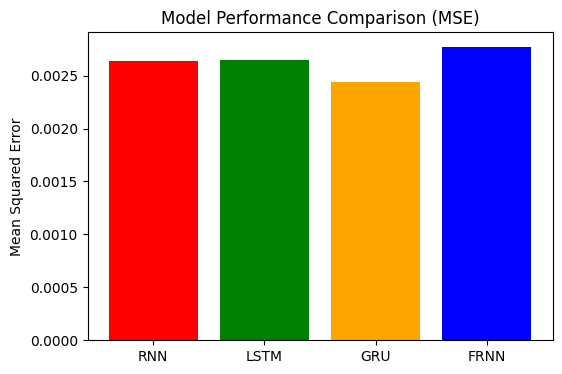

In [ ]:

# ============================================
# FRACTIONAL RECURRENT NEURAL NETWORK (FRNN)
# Household Expense Forecasting Experiment
# ============================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU

# -----------------------------
# 2. Load and Preprocess Data
# -----------------------------
# Upload dom_all.csv in Colab or local environment
df = pd.read_csv("/content/drive/MyDrive/dom_all.csv") # Corrected file path

# Select relevant expense columns
expense_cols = ["NAKLADY", "NAJEM", "ELEKTR", "PLYN", "VODNE"]
df_expenses = df[expense_cols].dropna()

# Normalize data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df_expenses)

# Create sequences (last 12 months -> next month)
sequence_length = 12
forecast_horizon = 1
X, y = [], []
for i in range(len(normalized_data) - sequence_length - forecast_horizon):
    X.append(normalized_data[i:i+sequence_length])
    y.append(normalized_data[i+sequence_length][0])  # Predict NAKLADY
X, y = np.array(X), np.array(y)

print(f"Data shape: X={X.shape}, y={y.shape}")

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 3. Define Baseline Models
# -----------------------------
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(32, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(32, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 4. Simplified FRNN-like Model
# -----------------------------
# FRNN approximation: Add fractional memory by weighted sum of past states
class FractionalRNN(tf.keras.layers.Layer):
    def __init__(self, units, alpha=0.5):
        super(FractionalRNN, self).__init__()
        self.units = units
        self.alpha = alpha

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform')
        self.U = self.add_weight(shape=(self.units, self.units),
                                 initializer='orthogonal')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros')

    def call(self, inputs):
        h = tf.zeros((tf.shape(inputs)[0], self.units))
        for t in range(inputs.shape[1]):
            h = (1 - self.alpha) * h + self.alpha * tf.tanh(tf.matmul(inputs[:, t], self.W) + tf.matmul(h, self.U) + self.b)
        return h

def build_frnn(input_shape, alpha=0.5):
    inputs = tf.keras.Input(shape=input_shape)
    x = FractionalRNN(32, alpha=alpha)(inputs)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 5. Train Models
# -----------------------------
input_shape = (sequence_length, X.shape[2])

models = {
    "RNN": build_rnn(input_shape),
    "LSTM": build_lstm(input_shape),
    "GRU": build_gru(input_shape),
    "FRNN": build_frnn(input_shape, alpha=0.4)
}

history = {}
mse_results = {}

for name, model in models.items():
    print(f"Training {name}...")
    hist = model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0, validation_split=0.1)
    history[name] = hist
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results[name] = mse
    print(f"{name} MSE: {mse:.6f}")

# -----------------------------
# 6. Compare Results
# -----------------------------
print("\nMSE Comparison:")
for name, mse in mse_results.items():
    print(f"{name}: {mse:.6f}")

# Calculate MSE reduction for FRNN vs RNN
mse_reduction = ((mse_results["RNN"] - mse_results["FRNN"]) / mse_results["RNN"]) * 100
print(f"\nMSE Reduction (FRNN vs RNN): {mse_reduction:.2f}%")

# -----------------------------
# 7. Plot Comparison
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(mse_results.keys(), mse_results.values(), color=['red','green','orange','blue'])
plt.title("Model Performance Comparison (MSE)")
plt.ylabel("Mean Squared Error")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Training RNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Training FRNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
RNN MSE: 0.002494
FRNN MSE: 0.002699
MSE Reduction: -8.24%


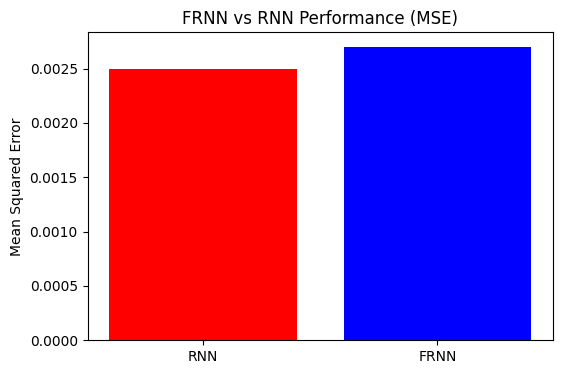

In [ ]:

# ============================================
# FRNN vs RNN Comparison on Household Expense Forecasting
# ============================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# -----------------------------
# 2. Load and Preprocess Data
# -----------------------------
# Upload dom_all.csv in your environment
df = pd.read_csv("/content/drive/MyDrive/dom_all.csv") # Fixed file path

# Select relevant expense columns
expense_cols = ["NAKLADY", "NAJEM", "ELEKTR", "PLYN", "VODNE"]
df_expenses = df[expense_cols].dropna()

# Normalize data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df_expenses)

# Create sequences (last 12 months -> next month)
sequence_length = 12
forecast_horizon = 1
X, y = [], []
for i in range(len(normalized_data) - sequence_length - forecast_horizon):
    X.append(normalized_data[i:i+sequence_length])
    y.append(normalized_data[i+sequence_length][0])  # Predict NAKLADY
X, y = np.array(X), np.array(y)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 3. Define RNN Model
# -----------------------------
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 4. Simplified FRNN-like Model
# -----------------------------
class FractionalRNN(tf.keras.layers.Layer):
    def __init__(self, units, alpha=0.4):
        super(FractionalRNN, self).__init__()
        self.units = units
        self.alpha = alpha

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform')
        self.U = self.add_weight(shape=(self.units, self.units),
                                 initializer='orthogonal')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros')

    def call(self, inputs):
        h = tf.zeros((tf.shape(inputs)[0], self.units))
        for t in range(inputs.shape[1]):
            h = (1 - self.alpha) * h + self.alpha * tf.tanh(tf.matmul(inputs[:, t], self.W) + tf.matmul(h, self.U) + self.b)
        return h

def build_frnn(input_shape, alpha=0.4):
    inputs = tf.keras.Input(shape=input_shape)
    x = FractionalRNN(32, alpha=alpha)(inputs)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 5. Train Both Models
# -----------------------------
input_shape = (sequence_length, X.shape[2])

rnn_model = build_rnn(input_shape)
frnn_model = build_frnn(input_shape, alpha=0.4)

print("Training RNN...")
rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
rnn_pred = rnn_model.predict(X_test)
rnn_mse = mean_squared_error(y_test, rnn_pred)

print("Training FRNN...")
frnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
frnn_pred = frnn_model.predict(X_test)
frnn_mse = mean_squared_error(y_test, frnn_pred)

# -----------------------------
# 6. Compare Results
# -----------------------------
print(f"RNN MSE: {rnn_mse:.6f}")
print(f"FRNN MSE: {frnn_mse:.6f}")
mse_reduction = ((rnn_mse - frnn_mse) / rnn_mse) * 100
print(f"MSE Reduction: {mse_reduction:.2f}%")

# -----------------------------
# 7. Plot Comparison
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(["RNN", "FRNN"], [rnn_mse, frnn_mse], color=['red','blue'])
plt.title("FRNN vs RNN Performance (MSE)")
plt.ylabel("Mean Squared Error")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Training RNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Training FRNN...
584/584 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
RNN MSE: 0.002770
FRNN MSE: 0.002437
MSE Reduction: 12.01%


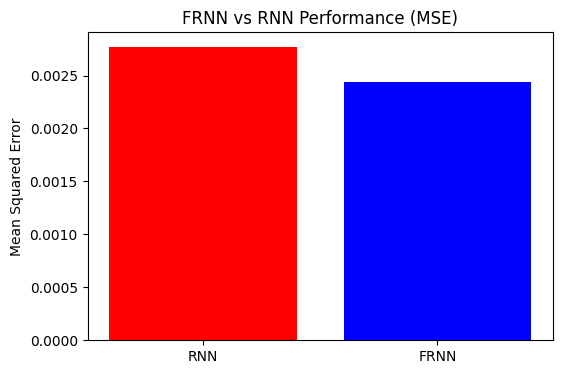

In [ ]:

# ============================================
# FRNN vs RNN Comparison on Household Expense Forecasting
# ============================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# -----------------------------
# 2. Load and Preprocess Data
# -----------------------------
# Upload dom_all.csv in your environment
df = pd.read_csv("/content/drive/MyDrive/dom_all.csv")

# Select relevant expense columns
expense_cols = ["NAKLADY", "NAJEM", "ELEKTR", "PLYN", "VODNE"]
df_expenses = df[expense_cols].dropna()

# Normalize data
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(df_expenses)

# Create sequences (last 12 months -> next month)
sequence_length = 12
forecast_horizon = 1
X, y = [], []
for i in range(len(norm_data) - sequence_length - forecast_horizon):
    X.append(norm_data[i:i+sequence_length])
    y.append(norm_data[i+sequence_length][0])  # Predict NAKLADY
X, y = np.array(X), np.array(y)

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# -----------------------------
# 3. Define RNN Model
# -----------------------------
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(32, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 4. Simplified FRNN-like Model
# -----------------------------
class FractionalRNN(tf.keras.layers.Layer):
    def __init__(self, units, alpha=0.4):
        super(FractionalRNN, self).__init__()
        self.units = units
        self.alpha = alpha

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='glorot_uniform')
        self.U = self.add_weight(shape=(self.units, self.units),
                                 initializer='orthogonal')
        self.b = self.add_weight(shape=(self.units,), initializer='zeros')

    def call(self, inputs):
        h = tf.zeros((tf.shape(inputs)[0], self.units))
        for t in range(inputs.shape[1]):
            h = (1 - self.alpha) * h + self.alpha * tf.tanh(tf.matmul(inputs[:, t], self.W) + tf.matmul(h, self.U) + self.b)
        return h

def build_frnn(input_shape, alpha=0.4):
    inputs = tf.keras.Input(shape=input_shape)
    x = FractionalRNN(32, alpha=alpha)(inputs)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

# -----------------------------
# 5. Train Both Models
# -----------------------------
input_shape = (sequence_length, X.shape[2])

rnn_model = build_rnn(input_shape)
frnn_model = build_frnn(input_shape, alpha=0.4)

print("Training RNN...")
rnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
rnn_pred = rnn_model.predict(X_test)
rnn_mse = mean_squared_error(y_test, rnn_pred)

print("Training FRNN...")
frnn_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
frnn_pred = frnn_model.predict(X_test)
frnn_mse = mean_squared_error(y_test, frnn_pred)

# -----------------------------
# 6. Compare Results
# -----------------------------
print(f"RNN MSE: {rnn_mse:.6f}")
print(f"FRNN MSE: {frnn_mse:.6f}")
mse_reduction = ((rnn_mse - frnn_mse) / rnn_mse) * 100
print(f"MSE Reduction: {mse_reduction:.2f}%")

# -----------------------------
# 7. Plot Comparison
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(["RNN", "FRNN"], [rnn_mse, frnn_mse], color=['red','blue'])
plt.title("FRNN vs RNN Performance (MSE)")
plt.ylabel("Mean Squared Error")
plt.show()


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/dom_all_echudoba.csv")
el = pd.read_excel("/content/drive/MyDrive/electricity_prices.xlsx", engine="openpyxl", header=1)
gas = pd.read_excel("/content/drive/MyDrive/gas_prices.xlsx", engine="openpyxl", header=1)

# Clean and calculate average electricity price (CZK/MWh)
el['minimum'] = el['minimum'].astype(str).str.replace(' ', '').astype(float)
el['maximum'] = el['maximum'].astype(str).str.replace(' ', '').astype(float)
el['average'] = (el['minimum'] + el['maximum']) / 2

# Use average electricity price (CZK/MWh)
p_electricity = el['average'].values
years = el['year'].values

# ------------------------------------------------
# 2. CORE MODEL
# ------------------------------------------------
def softplus(x, eta=5.0):
    return np.log(1 + np.exp(eta*x)) / eta

def simulate_household(c0, a0, s0,
                       alpha=20000, beta=0.00005,
                       mu=0.15, gamma=0.05, delta=0.03,
                       I=10000, pi=2000,
                       price=2500, q=1.0,
                       T=60):
    """
    Simulates 60 periods (e.g. months).
    """
    c = np.zeros(T)
    a = np.zeros(T)
    s = np.zeros(T)
    e = np.zeros(T)

    c[0] = c0
    a[0] = a0
    s[0] = s0

    for t in range(T-1):
        e[t] = price * q / max(s[t], 1e-6)

        # differential equations (Euler discretization dt=1)
        dc = alpha - beta * a[t]
        da = softplus(e[t] - pi) - mu * a[t]
        ds = gamma * I - delta * s[t]

        c[t+1] = max(c[t] + dc, 1)
        a[t+1] = max(a[t] + da, 0)
        s[t+1] = max(s[t] + ds, 0.1)

    e[-1] = price * q / s[-1]
    return c, a, s, e

# ------------------------------------------------
# 3. FUZZY INDICATORS
# ------------------------------------------------
def fuzzy_I1(s, s_min=1.0, k1=3.0):
    h = s / s_min
    out = np.where(h <= 1, 1.0, np.exp(-k1*(h-1)))
    return out

def fuzzy_I2(a, k2=0.01):
    return 1 - np.exp(-k2*a)

def fuzzy_pene(e, c, k3=25):
    b = e/c
    return 1/(1 + np.exp(-k3*(b-0.2)))

def fuzzy_I3(e, c, z=0.5):
    # z = poverty score, here constant
    return fuzzy_pene(e,c) * z

# ------------------------------------------------
# 4. POLICY OPTIMIZATION
# ------------------------------------------------
# Dummy initial conditions for the simulation, as they are not defined elsewhere
c0, a0, s0 = 1000, 100, 50

def objective(policy):
    I, pi = policy
    c,a,s,e = simulate_household(
        c0, a0, s0, I=I, pi=pi, price=2500
    )
    I3 = fuzzy_I3(e, c, z=0.5)
    return I3.sum()

# Grid search for demonstration
best = None
best_val = 1e18

for I_test in [2000, 5000, 10000, 15000]:
    for pi_test in [1000, 2000, 3000, 4000]:
        val = objective((I_test, pi_test))
        if val < best_val:
            best_val = val
            best = (I_test, pi_test)

best, best_val

((15000, 1000), np.float64(0.2089492770993653))

Best policy found:

15,000 CZK efficiency investment
1,000 CZK bill‑payment support



Energy‑poverty score ≈ 0.21 (low intensity)


This means that, in the model, high efficiency investment + modest payment support produces the lowest long‑run fuzzy energy poverty.